In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.getcwd()

'C:\\Users\\HP\\OneDrive\\Desktop\\Data-Cleaning-Project\\notebooks'

In [5]:
import os
os.listdir("../data")

['Online Retail.xlsx', '~$Online Retail.xlsx']

In [1]:
import pandas as pd

df = pd.read_csv("../data/Online Retail.csv", nrows=1000)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [2]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    1000 non-null   str    
 1   StockCode    1000 non-null   str    
 2   Description  999 non-null    str    
 3   Quantity     1000 non-null   int64  
 4   InvoiceDate  1000 non-null   str    
 5   UnitPrice    1000 non-null   float64
 6   CustomerID   999 non-null    float64
 7   Country      1000 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 62.6 KB


In [4]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,1000.000000,1000.000000,999.000000
mean,12.785000,3.037110,16023.130130
std,38.423706,5.896942,1865.129933
min,-24.000000,0.000000,12431.000000
25%,2.000000,1.250000,14688.000000
50%,4.000000,2.100000,16210.000000
75%,12.000000,3.750000,17908.000000
max,600.000000,165.000000,18085.000000


In [5]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    1
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     1
Country        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(23)

In [7]:
df.dtypes

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

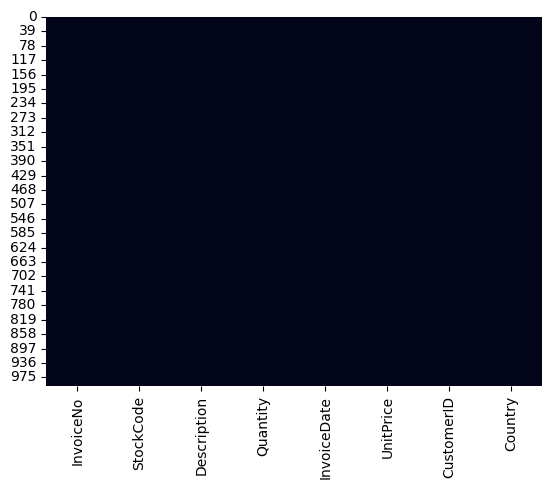

In [10]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

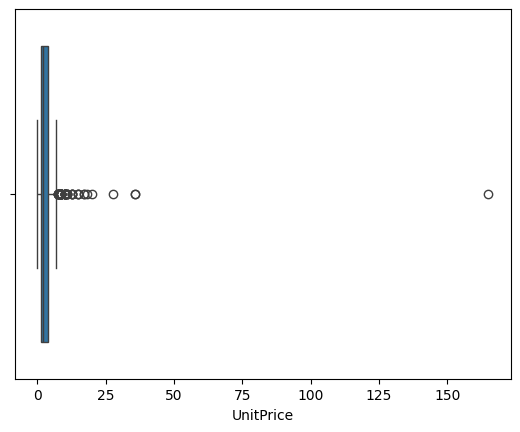

In [11]:
sns.boxplot(x=df['UnitPrice'])
plt.show()

In [12]:
df = df.dropna()

In [13]:
df = df.drop_duplicates()

In [14]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
df = df[df['Quantity'] > 0]

In [16]:
df = df[df['UnitPrice'] > 0]

In [17]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [18]:
df['Year'] = df['InvoiceDate'].dt.year

In [19]:
df['Month'] = df['InvoiceDate'].dt.month

In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 966 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    966 non-null    str           
 1   StockCode    966 non-null    str           
 2   Description  966 non-null    str           
 3   Quantity     966 non-null    int64         
 4   InvoiceDate  966 non-null    datetime64[us]
 5   UnitPrice    966 non-null    float64       
 6   CustomerID   966 non-null    float64       
 7   Country      966 non-null    str           
 8   TotalPrice   966 non-null    float64       
 9   Year         966 non-null    int32         
 10  Month        966 non-null    int32         
dtypes: datetime64[us](1), float64(3), int32(2), int64(1), str(4)
memory usage: 83.0 KB


In [21]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
dtype: int64

In [22]:
df.to_csv("../cleaned_data/cleaned_retail_data.csv", index=False)